In [1]:
!pip install gdown
!pip install -q transformers torch sentencepiece huggingface_hub

In [2]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.3 MB/s eta 0:00:00


In [ ]:
import os
import re
import math
import random
import string
import warnings

import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from underthesea import text_normalize
from tqdm import tqdm

warnings.filterwarnings('ignore')

2026-05-21 00:00:56.055650: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779321656.311394      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779321656.377275      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779321656.932185      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779321656.932232      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779321656.932235      23 computation_placer.cc:177] computation placer alr

In [4]:
# Cài đặt wrapper Python cho VnCoreNLP.
!pip install vncorenlp

# Tải xuống VnCoreNLP và thành phần phân đoạn từ (RDRSegmenter).
!mkdir -p vncorenlp/models/wordsegmenter
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr
!mv VnCoreNLP-1.1.1.jar vncorenlp/
!mv vi-vocab vncorenlp/models/wordsegmenter/
!mv wordsegmenter.rdr vncorenlp/models/wordsegmenter/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=a85d28296e607d6d6709d7cd33f66d64ba8f01d5664fe7aa383ae69b717880eb
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp
--2026-05-21 00:01:42--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412575 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.1.1.jar’

VnCoreNLP-1.1.1.jar 100%[===================>]  26.14M  --.-KB/s    in 0.1s    

2026-05-21 00:01:42 (182 MB/s) - ‘VnCoreNLP

In [5]:
from vncorenlp import VnCoreNLP
# Khởi tạo RDRSegmenter từ VnCoreNLP để phân đoạn từ tiếng Việt.
rdrsegmenter = VnCoreNLP(
    "vncorenlp/VnCoreNLP-1.1.1.jar", 
    annotators="wseg", 
    max_heap_size='-Xmx500m')

text = "thầy nhiệt tình giảng dạy, gần gũi với sinh viên"

# Phân đoạn từ cho đoạn văn bản tiếng Việt.
word_segmented_text = rdrsegmenter.tokenize(text)
print(word_segmented_text)

[['thầy', 'nhiệt_tình', 'giảng_dạy', ',', 'gần_gũi', 'với', 'sinh_viên']]


In [6]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

TRAIN_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/old_train_llm_final_gda.csv"
VAL_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/val_final.csv"
TEST_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/test_final.csv"


# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
# train_df = load_split("train", URLS["train"])
val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

def load_data_from_csv():
    try:
        # Load file đã cập nhật nhãn
        train_df = pd.read_csv(TRAIN_PATH)
        val_df = pd.read_csv(VAL_PATH)
        test_df1 = pd.read_csv(TEST_PATH)
        
        print("--- Thông tin dữ liệu đã load ---")
        print(f"Tập Train: {len(train_df)} mẫu")
        print(f"Tập Val  : {len(val_df)} mẫu")
        print(f"Tập Test  : {len(test_df1)} mẫu")
        
        
        # return train_df, val_df, test_df1
        return train_df, test_df1
    
    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file. Hãy chắc chắn bạn đã chạy bước xuất CSV trước đó. \nChi tiết: {e}")
        return None, None

# 2. Thực thi load dữ liệu
# train_df, val_df, test_df1 = load_data_from_csv()
train_df, test_df1 = load_data_from_csv()

--- Thông tin dữ liệu đã load ---
Tập Train: 16715 mẫu
Tập Val  : 1583 mẫu
Tập Test  : 3166 mẫu


In [7]:
train_df

,sentence,sentiment,topic,is_augmented
0,có nhiều ví dụ minh họa dễ hiểu .,2,0,False
1,cung cấp tài liệu đầy đủ .,2,0,False
2,"Lượng bài tập cô cho hơi bị khủng, mà cũng oke...",1,0,True
3,dặn sinh viên tham gia seminar một cách tự ngu...,0,0,False
4,Nội dung giảng dạy có theo đúng khung chương t...,1,1,True
...,...,...,...,...
16710,thầy tuy nhỏ người nhưng có giọng nói rất to r...,2,0,False
16711,"Phòng nóng lắm, máy chiếu thì mờ tịt.",0,2,True
16712,thầy dạy nhàm chán buồn ngủ .,0,0,False
16713,thầy hướng dẫn thực hành hay .,2,0,False


# Preprocessing

In [ ]:
def load_external_teencode(file_path):
    """Hàm đọc file teencode.txt từ Kaggle và chuyển thành Dictionary"""
    external_dict = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Thông thường file teencode.txt trên Kaggle phân tách bằng dấu Tab (\t)
                # Nếu file dùng định dạng khác (như dấu phẩy), hãy đổi split('\t') thành split(',')
                parts = line.strip().split('\t') 
                if len(parts) >= 2:
                    teencode = parts[0].strip().lower()
                    standard = parts[1].strip().lower()
                    external_dict[teencode] = standard
        print(f"Đã tải thành công {len(external_dict)} từ teencode từ file Kaggle.")
    except Exception as e:
        print(f"Lỗi khi đọc file teencode: {e}")
    return external_dict

# Từ điển giải mã Emoticon đặc thù của dữ liệu UIT-VSFC
UIT_VSFC_EMOTICON_DICT = {
    "colonsmilesmile": "rất vui", "colondoublesurprise": "rất bất ngờ",
    "colonbigsmile": "cười to", "colonsadcolon": "rất buồn",
    "colonsmalsmile": "mỉm cười", "colonsmile": "vui vẻ",
    "colonlove": "yêu thích", "colonsad": "buồn bã",
    "colonhihi": "vui vẻ", "coloncontemn": "chê bai",
    "coloncolon": "bối rối" 
}

# Từ điển tự định nghĩa (Mang tính cục bộ của môi trường đại học)
CUSTOM_TEENCODE_DICT = {
    "ko": "không", "k": "không", "kh": "không", "khg": "không", "kg": "không",
    "dc": "được", "đc": "được", "duoc": "được",
    "sv": "sinh viên", "gv": "giảng viên", "thầy cô": "giảng viên",
    "vs": "với", "r": "rồi", "ah": "à", "nhìu": "nhiều",
    "bt": "bình thường", "tot": "tốt", "thik": "thích", 
    "ntn": "như thế nào", "nv": "nhân viên", "cs vc": "cơ sở vật chất",
    "csvc": "cơ sở vật chất", "wifi": "mạng", "phong": "phòng", "vkl": "vô cùng",
    "vl": "vô cùng", "vcl": "vô cùng", "đm": "chửi thề", "vãi": "rất"
}

# Tiến hành hợp nhất 2 từ điển
KAGGLE_FILE_PATH = '/kaggle/input/datasets/taiduong1/vietnamese-teencode/teencode.txt'

# Bước 1: Load file gốc
FINAL_TEENCODE_DICT = load_external_teencode(KAGGLE_FILE_PATH)

# Bước 2: Dùng lệnh .update() để hợp nhất. 
# Từ điển CUSTOM sẽ ghi đè lên EXTERNAL nếu có các key trùng lặp.
FINAL_TEENCODE_DICT.update(CUSTOM_TEENCODE_DICT)

print(f"Tổng số từ khóa teencode hiện có trong bộ lọc: {len(FINAL_TEENCODE_DICT)}")

def clean_vietnamese_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Dùng thư viện ngoài để chuẩn hóa Unicode
    text = text_normalize(text).lower()
    
    # 2. Giải mã các chuỗi emoticon đặc thù
    for encoded_emo, meaning in UIT_VSFC_EMOTICON_DICT.items():
        text = re.sub(r'\b' + re.escape(encoded_emo) + r'\b', f" {meaning} ", text)
        
    # 3. Chuẩn hóa Teencode bằng TỪ ĐIỂN ĐÃ HỢP NHẤT
    for word, true_word in FINAL_TEENCODE_DICT.items():
        text = re.sub(r'\b' + re.escape(word) + r'\b', f" {true_word} ", text)
        
    # 4. Loại bỏ dấu câu (Punctuation)
    punctuations = string.punctuation + '”’“‘…—'
    for p in punctuations:
        text = text.replace(p, ' ')
        
    # 5. Loại bỏ kí tự rác (Chỉ giữ chữ cái tiếng Việt, số, khoảng trắng)
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]', ' ', text)
    
    # 6. Chuẩn hóa khoảng trắng liên tiếp
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

train_df['cleaned_text'] = train_df['sentence'].apply(clean_vietnamese_text)
val_df['cleaned_text'] = val_df['sentence'].apply(clean_vietnamese_text)
test_df['cleaned_text'] = test_df['sentence'].apply(clean_vietnamese_text)
test_df1['cleaned_text'] = test_df1['sentence'].apply(clean_vietnamese_text)

Đã tải thành công 389 từ teencode từ file Kaggle.
Tổng số từ khóa teencode hiện có trong bộ lọc: 406


# Segment toàn bộ dataset

In [ ]:
def word_segment(text):
    if not isinstance(text, str):
        return ""
    try:
        tokens = rdrsegmenter.tokenize(text)
        return " ".join([w for sent in tokens for w in sent])
    except Exception:
        return text

train_df['sentence_seg'] = train_df['cleaned_text'].apply(word_segment)
val_df['sentence_seg'] = val_df['cleaned_text'].apply(word_segment)
test_df['sentence_seg'] = test_df['cleaned_text'].apply(word_segment)
test_df1['sentence_seg'] = test_df1['cleaned_text'].apply(word_segment)

train_df.head()

,sentence,sentiment,topic,is_augmented,cleaned_text,sentence_seg
0,có nhiều ví dụ minh họa dễ hiểu .,2,0,False,có nhiều ví dụ minh họa dễ hiểu,có nhiều ví_dụ minh_hoạ dễ hiểu
1,cung cấp tài liệu đầy đủ .,2,0,False,cung cấp tài liệu đầy đủ,cung_cấp tài_liệu đầy_đủ
2,"Lượng bài tập cô cho hơi bị khủng, mà cũng oke...",1,0,True,lượng bài tập cô cho hơi bị khủng mà cũng oke ...,lượng bài_tập cô cho hơi bị khủng mà cũng oke ...
3,dặn sinh viên tham gia seminar một cách tự ngu...,0,0,False,dặn sinh viên tham gia seminar một cách tự ngu...,dặn sinh_viên tham_gia seminar một_cách tự_ngu...
4,Nội dung giảng dạy có theo đúng khung chương t...,1,1,True,nội dung giảng dạy có theo đúng khung chương t...,nội_dung giảng_dạy có theo đúng khung chương_t...


# B5a MTL Hard Sharing + PCGrad + CE
# B5b MTL Hard Sharing + PCGrad + WCE
# B5c MTL Hard Sharing + PCGrad + Focal Loss
# B5d MTL Hard Sharing + PCGrad + ASL

In [ ]:
# config
MODEL_NAME   = "vinai/phobert-base"
MAX_LEN      = 128
BATCH_SIZE   = 32
ACCUM_STEPS  = 1
LR           = 2e-5
LR_ENCODER   = 2e-5   
LR_HEADS     = 1e-4   # LR cho Classification Heads và Cross-Attention
DROPOUT      = 0.3    
EPOCHS       = 20
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
PATIENCE      = 5      
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_SENTIMENT = 3   # Negative=0, Neutral=1, Positive=2
NUM_TOPIC     = 4   # Lecturer=0, Training=1, Facility=2, Others=3

# Tên nhãn dùng nhất quán trong toàn bộ file
SENT_NAMES  = ["Negative", "Neutral", "Positive"]
TOPIC_NAMES = ["Lecturer", "Training Program", "Facility", "Others"]
 
print(f"Device : {DEVICE}")
print(f"Encoder: {MODEL_NAME}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# tokenizer 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# DATASET CLASS
class FeedbackDataset(Dataset):
    def __init__(self, sentences, sentiments, topics, tokenizer, max_len):
        self.sentences  = sentences
        self.sentiments = sentiments
        self.topics     = topics
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "sentiment":      torch.tensor(self.sentiments[idx], dtype=torch.long),
            "topic":          torch.tensor(self.topics[idx],     dtype=torch.long),
        }

def make_loader(df, shuffle=True):
    ds = FeedbackDataset(
        # df["sentence"].tolist(),
        df["sentence_seg"].tolist(), 
        df["sentiment"].tolist(),
        df["topic"].tolist(),
        tokenizer, MAX_LEN
    )
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df,   shuffle=False)
test_loader  = make_loader(test_df,  shuffle=False)
test_loader1  = make_loader(test_df1,  shuffle=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Test relabled: {len(test_df1)}")

# CLASS WEIGHTS 
def compute_class_weights(labels, num_classes):
    """Inverse frequency weighting."""
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes   # normalize
    return torch.tensor(weights, dtype=torch.float32)

def compute_focal_alpha(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    """
    Alpha cho Focal Loss.
    Normalize về sum = 1 (không nhân num_classes).
    """
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    alpha  = 1.0 / (counts + 1e-8)
    alpha  = alpha / alpha.sum()
    return torch.tensor(alpha, dtype=torch.float32)

sent_weights  = compute_class_weights(train_df["sentiment"].values, NUM_SENTIMENT)
topic_weights = compute_class_weights(train_df["topic"].values,     NUM_TOPIC)
sent_focal_alpha  = compute_focal_alpha(train_df["sentiment"].values, NUM_SENTIMENT)
topic_focal_alpha = compute_focal_alpha(train_df["topic"].values,     NUM_TOPIC)
print("Sentiment weights:", sent_weights.round(decimals=3))
print("Topic weights    :", topic_weights.round(decimals=3))
print("Focal alpha  (sentiment):", sent_focal_alpha.numpy().round(4))
print("Focal alpha  (topic)    :", topic_focal_alpha.numpy().round(4))

def predict_test(model, loader, task):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())
    return f1_score(all_labels, all_preds, average="macro"), all_labels, all_preds

def evaluate_and_plot(model, loader, task, target_names, title="Confusion Matrix"):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            y_pred.extend(logits.argmax(-1).cpu().tolist())
            y_true.extend(batch[task].tolist())
            
    print(f"\n=== {title.upper()} ===")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    return classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)

def plot_training_history(history_df, title="Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ 1: Train Loss vs Val Loss
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', color='tab:red')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='s', color='tab:orange')
    ax1.set_title('Mức độ lỗi (Loss) qua các Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Biểu đồ 2: Train F1 vs Val F1
    ax2.plot(history_df['epoch'], history_df['train_f1'], label='Train Macro F1', marker='o', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['val_f1'], label='Val Macro F1', marker='s', color='tab:green')
    ax2.set_title('Độ chính xác (Macro F1) qua các Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chẩn đoán trên tập val trước khi lưu test cho MTL
def diagnose_validation(model, val_loader, model_name):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số"""
    model.eval()
    s_preds, s_labels, t_preds, t_labels = [], [], [], []
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            s_logit, t_logit = model(ids, mask)
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    print(f"\nChấn đoán trên validation === {model_name} ===")
    print("SENTIMENT:")
    print(classification_report(s_labels, s_preds, target_names=["Negative", "Neutral", "Positive"], digits=4))
    print("TOPIC:")
    print(classification_report(t_labels, t_preds, target_names=["Lecturer", "Training", "Facility", "Others"], digits=4))

# Chẩn đoán trên tập val trước khi lưu test cho STL
def diagnose_validation_single_task(model, val_loader, model_name, task):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số cho Single-Task"""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Mô hình single-task chỉ trả về 1 logit
            logits = model(ids, mask)
            
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())

    print(f"\nChẩn đoán validation === {model_name} ({task.upper()}) ===")
    
    if task == "sentiment":
        target_names = ["Negative", "Neutral", "Positive"]
    elif task == "topic":
        target_names = ["Lecturer", "Training", "Facility", "Others"]
    else:
        target_names = None
        
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

Device : cuda
Encoder: vinai/phobert-base


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 16715 | Val: 1583 | Test: 3166 | Test relabled: 3166
Sentiment weights: tensor([0.3400, 2.1880, 0.4720])
Topic weights    : tensor([0.3260, 0.6190, 1.4020, 1.6530])
Focal alpha  (sentiment): [0.1132 0.7294 0.1573]
Focal alpha  (topic)    : [0.0816 0.1547 0.3505 0.4132]


In [ ]:
# Hard Sharing 
class MTLHardSharing(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.sent_head(cls), self.topic_head(cls)

# Cross-Task Attention
class CrossTaskAttention(nn.Module):
    def __init__(self, hidden_size, num_heads=4, dropout=0.3):
        super().__init__()
        self.attn_s2t = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.attn_t2s = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.norm_s   = nn.LayerNorm(hidden_size)
        self.norm_t   = nn.LayerNorm(hidden_size)

    def forward(self, sent_repr, topic_repr):
        s_refined, _ = self.attn_s2t(sent_repr.unsqueeze(1), topic_repr.unsqueeze(1), topic_repr.unsqueeze(1))
        t_refined, _ = self.attn_t2s(topic_repr.unsqueeze(1), sent_repr.unsqueeze(1), sent_repr.unsqueeze(1))
        s_out = self.norm_s(sent_repr + s_refined.squeeze(1))
        t_out = self.norm_t(topic_repr + t_refined.squeeze(1))
        return s_out, t_out

class MTLCrossTask(nn.Module):
    is_mtl = True
    def __init__(self, dropout=0.3, head_dropout=0.3): # Thêm tham số head_dropout
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden = self.encoder.config.hidden_size

        self.sent_proj  = nn.Linear(hidden, hidden)
        self.topic_proj = nn.Linear(hidden, hidden)
        self.cross_attn = CrossTaskAttention(hidden, num_heads=4, dropout=dropout)
        self.dropout    = nn.Dropout(dropout)
        self.head_dropout = nn.Dropout(head_dropout) # Dropout tăng cường trước classification

        self.sent_head  = nn.Linear(hidden, NUM_SENTIMENT)
        self.topic_head = nn.Linear(hidden, NUM_TOPIC)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [B, H]

        s_repr = self.dropout(torch.relu(self.sent_proj(cls)))
        t_repr = self.dropout(torch.relu(self.topic_proj(cls)))

        s_refined, t_refined = self.cross_attn(s_repr, t_repr)
        
        # Áp dụng head_dropout trước khi chẻ nhánh
        return self.sent_head(self.head_dropout(s_refined)), self.topic_head(self.head_dropout(t_refined))

class MTLSoftSharing(nn.Module):
    is_mtl = True  
    
    def __init__(self, model_name=MODEL_NAME, num_sentiment=3, num_topic=4, dropout=0.3):
        super(MTLSoftSharing, self).__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        self.sent_tower = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU()
        )
        
        self.topic_tower = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU()
        )
        
        self.cross_stitch_sent = nn.Parameter(torch.tensor([0.9, 0.1])) 
        self.cross_stitch_topic = nn.Parameter(torch.tensor([0.1, 0.9]))
        
        # TẠO 2 DROPOUT RIÊNG BIỆT CHO 2 TASK
        self.dropout_s = nn.Dropout(dropout)
        self.dropout_t = nn.Dropout(dropout)
        
        self.sent_head = nn.Linear(hidden_size, num_sentiment)
        self.topic_head = nn.Linear(hidden_size, num_topic)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        
        rep_sent = self.sent_tower(cls_output)
        rep_topic = self.topic_tower(cls_output)
        
        w_sent = torch.softmax(self.cross_stitch_sent, dim=0)
        w_topic = torch.softmax(self.cross_stitch_topic, dim=0)
        
        shared_sent = w_sent[0] * rep_sent + w_sent[1] * rep_topic
        shared_topic = w_topic[0] * rep_sent + w_topic[1] * rep_topic
        
        # ÁP DỤNG LỚP DROPOUT ĐỘC LẬP
        shared_sent = self.dropout_s(shared_sent)
        shared_topic = self.dropout_t(shared_topic)
        
        logits_sent = self.sent_head(shared_sent)
        logits_topic = self.topic_head(shared_topic)
        
        return logits_sent, logits_topic


# KIẾN TRÚC MMOE (MULTI-GATE MIXTURE-OF-EXPERTS)
class ExpertNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(ExpertNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3), # Đồng bộ dropout 0.3 để giảm overfit
            nn.Linear(hidden_dim, hidden_dim)
        )
        
    def forward(self, x):
        return self.network(x)

class MMoE_PhoBERT(nn.Module):
    is_mtl = True 
    
    def __init__(self, model_name=MODEL_NAME, num_experts=4, expert_dim=256, num_sentiment=NUM_SENTIMENT, num_topic=NUM_TOPIC):
        super(MMoE_PhoBERT, self).__init__()
        
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        # Tập hợp các chuyên gia
        self.experts = nn.ModuleList([
            ExpertNetwork(hidden_size, expert_dim) for _ in range(num_experts)
        ])
        
        # Mạng cổng (Gates) điều hướng chuyên gia cho từng tác vụ
        self.gate_sentiment = nn.Sequential(
            nn.Linear(hidden_size, num_experts),
            nn.Softmax(dim=1)
        )
        self.gate_topic = nn.Sequential(
            nn.Linear(hidden_size, num_experts),
            nn.Softmax(dim=1)
        )
        
        # Dropout bổ sung trước khi phân loại
        self.head_dropout = nn.Dropout(0.3)
        
        # Lớp phân loại
        self.head_sentiment = nn.Linear(expert_dim, num_sentiment)
        self.head_topic = nn.Linear(expert_dim, num_topic)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_repr = outputs.last_hidden_state[:, 0, :] 
        
        expert_outputs = torch.stack([expert(cls_repr) for expert in self.experts], dim=1)
        
        w_sentiment = self.gate_sentiment(cls_repr).unsqueeze(-1)
        w_topic = self.gate_topic(cls_repr).unsqueeze(-1)
        
        repr_sentiment = torch.sum(w_sentiment * expert_outputs, dim=1)
        repr_topic = torch.sum(w_topic * expert_outputs, dim=1)
        
        logits_sentiment = self.head_sentiment(self.head_dropout(repr_sentiment))
        logits_topic = self.head_topic(self.head_dropout(repr_topic))
        
        return logits_sentiment, logits_topic
        
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # tensor shape [num_classes]
        self.gamma = gamma
        
    def forward(self, logits, targets):
        # Cross-entropy từng sample, không reduction
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)                      # xác suất đúng
        alpha_t = self.alpha.to(logits.device)[targets]
        fl = alpha_t * (1 - pt) ** self.gamma * ce
        return fl.mean()

class ClassSpecificAsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg_list, gamma_pos_list, clip=0.05, eps=1e-8):
        super(ClassSpecificAsymmetricLoss, self).__init__()
        self.register_buffer('gamma_neg', torch.tensor(gamma_neg_list, dtype=torch.float32))
        self.register_buffer('gamma_pos', torch.tensor(gamma_pos_list, dtype=torch.float32))
        self.clip = clip
        self.eps = eps

    def forward(self, x, y):
        num_classes = x.size(1)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        
        # Dùng sigmoid thay vì softmax
        xs_pos = torch.sigmoid(x)
        xs_neg = 1.0 - xs_pos
        
        # Probability shifting
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Cross Entropy cơ bản
        los_pos = y_onehot * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y_onehot) * torch.log(xs_neg.clamp(min=self.eps))
        
        # Mở rộng ma trận Gamma
        gamma_pos_t = self.gamma_pos.unsqueeze(0).expand_as(x)
        gamma_neg_t = self.gamma_neg.unsqueeze(0).expand_as(x)

        # Tính xác suất tổng hợp và Gamma tương ứng
        pt = (xs_pos * y_onehot) + (xs_neg * (1 - y_onehot))
        one_sided_gamma = (gamma_pos_t * y_onehot) + (gamma_neg_t * (1 - y_onehot))
        
        # Trọng số Asymmetric
        one_sided_w = torch.pow(1 - pt, one_sided_gamma)
        
        loss = -(los_pos + los_neg) * one_sided_w
        return loss.sum(dim=-1).mean()


def train_mtl(model, train_loader, val_loader, loss_fn_sent, loss_fn_topic, 
              lambda_s=0.6, lambda_t=0.4, accum_steps=ACCUM_STEPS, model_name="mtl", patience=PATIENCE):
    
    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR_ENCODER},
        {'params': head_params, 'lr': LR_HEADS}
    ], weight_decay=WEIGHT_DECAY)
    
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)
            
            logits_s, logits_t = model(ids, mask)
            
            loss_s = loss_fn_sent(logits_s, targets_s)
            loss_t = loss_fn_topic(logits_t, targets_t)
            
            # Đồng bộ toán học: Chia tỷ lệ tích lũy chính xác
            loss = ((lambda_s * loss_s) + (lambda_t * loss_t)) / accum_steps
            loss.backward()
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            # train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
            # train_loss += (((loss_s * lambda_s) + (loss_t * lambda_t)) / accum_steps).item()
            train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()

        train_loss = train_loss / len(train_loader)

        # PHA KIỂM CHỨNG (VALIDATION)
        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s = [], []
        val_preds_t, val_targets_t = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                logits_s, logits_t = model(ids, mask)
                
                loss_s = loss_fn_sent(logits_s, targets_s)
                loss_t = loss_fn_topic(logits_t, targets_t)
                
                # Đồng bộ lambda nghiêm ngặt giống hệt pha Train
                loss = (lambda_s * loss_s) + (lambda_t * loss_t)
                
                val_loss += loss.item()
                val_preds_s.extend(logits_s.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(logits_t.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "sent_macro_f1": val_f1_s, "topic_macro_f1": val_f1_t
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Sent F1: {val_f1_s:.4f} | Val Topic F1: {val_f1_t:.4f} | Avg Val F1: {val_avg_f1:.4f}")

        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"New best (Avg Val F1: {best_avg_f1:.4f})")
        else:
            no_improve += 1
            print(f"Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Early stopping tại epoch {epoch}!")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    torch.save(best_state, f"{model_name}_best_01.pt")
    return model, pd.DataFrame(history), best_avg_f1
    
def plot_mtl_history(history_df, title="MTL Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Trục Loss (Vẽ cả Train Loss và Val Loss)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', color='tab:orange', marker='s')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Trục F1 (vẽ 2 đường cho 2 task trên tập Validation)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation Macro F1', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['sent_macro_f1'], label='Val Sentiment F1', color='tab:blue', marker='o')
    ax2.plot(history_df['epoch'], history_df['topic_macro_f1'], label='Val Topic F1', color='tab:green', marker='^')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title, fontweight='bold')
    fig.tight_layout()
    
    # Gộp legend của cả 2 trục cho gọn
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
    
    plt.grid(True, alpha=0.3)
    plt.show()
    

def evaluate_and_plot_mtl(model, loader, title_prefix="B1"):
    model.eval()
    s_preds, s_labels = [], []
    t_preds, t_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Khác biệt là ở đây: lấy ra 2 logits
            s_logit, t_logit = model(ids, mask)
            
            s_preds.extend(s_logit.argmax(-1).cpu().tolist())
            t_preds.extend(t_logit.argmax(-1).cpu().tolist())
            s_labels.extend(batch["sentiment"].tolist())
            t_labels.extend(batch["topic"].tolist())

    # --- IN REPORT ---
    print(f"\n=== {title_prefix}: SENTIMENT REPORT ===")
    sent_names = ["Negative", "Neutral", "Positive"]
    print(classification_report(s_labels, s_preds, target_names=sent_names, digits=4))

    print(f"\n=== {title_prefix}: TOPIC REPORT ===")
    topic_names = ["Lecturer", "Training Program", "Facility", "Others"]
    print(classification_report(t_labels, t_preds, target_names=topic_names, digits=4))

    # --- VẼ CONFUSION MATRIX (2 HÌNH) ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm_sent = confusion_matrix(s_labels, s_preds)
    sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=sent_names, yticklabels=sent_names)
    axes[0].set_title(f"Sentiment CM ({title_prefix})")
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    cm_topic = confusion_matrix(t_labels, t_preds)
    sns.heatmap(cm_topic, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
                xticklabels=topic_names, yticklabels=topic_names)
    axes[1].set_title(f"Topic CM ({title_prefix})")
    axes[1].set_ylabel('Actual')
    axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()
    
    # Trả về kết quả để lưu vào bảng tổng kết
    return {
        "sent_macro_f1":  f1_score(s_labels, s_preds, average="macro"),
        "topic_macro_f1": f1_score(t_labels, t_preds, average="macro"),
        "sent_report":    classification_report(s_labels, s_preds, target_names=sent_names, digits=4, output_dict=True),
        "topic_report":   classification_report(t_labels, t_preds, target_names=topic_names, digits=4, output_dict=True),
    }

In [ ]:
# PCGrad optimizer wrapper 
class PCGrad:
    """
    Project Conflicting Gradients — Yu et al. 2020.
    Xử lý an toàn theo từng tham số (Parameter-by-Parameter).
    Đã hỗ trợ Gradient Accumulation.
    """
    def __init__(self, optimizer):
        self.optimizer = optimizer

    def zero_grad(self):
        self.optimizer.zero_grad(set_to_none=True)

    def step(self):
        self.optimizer.step()

    def pc_backward(self, losses):
        # Lấy tham số từ TẤT CẢ các nhóm (để không bỏ sót Head)
        params = [p for group in self.optimizer.param_groups for p in group['params'] if p.requires_grad]
        num_tasks = len(losses)
        
        # Lấy chính xác trạng thái gradient tích lũy hiện thời trước khi bị zero_grad làm rỗng
        saved_grads = [p.grad.clone() if p.grad is not None else torch.zeros_like(p) for p in params]
        
        # 1. Thu thập gradient cho từng task
        grads = []
        for i, loss in enumerate(losses):
            self.optimizer.zero_grad(set_to_none=True)
            loss.backward(retain_graph=True)
            
            task_grads = []
            for p in params:
                if p.grad is not None:
                    task_grads.append(p.grad.detach().clone().flatten())
                else:
                    task_grads.append(torch.zeros_like(p).flatten())
            grads.append(task_grads)

        # 2. PCGrad Projection (Chiếu các gradient xung đột)
        proj_grads = [list(g) for g in grads]
        for i in range(num_tasks):
            indices = list(range(num_tasks))
            np.random.shuffle(indices)
            for j in indices:
                if i == j: continue
                for k in range(len(params)):
                    g_i = proj_grads[i][k]
                    g_j = grads[j][k]
                    
                    # Tính toán dot product
                    dot_p = torch.dot(g_i, g_j)
                    if dot_p < 0:
                        proj_grads[i][k] = g_i - (dot_p / (torch.norm(g_j)**2 + 1e-8)) * g_j

        # 3. Ghi đè gradient tổng hợp và cộng dồn lũy tiến vào saved_grads ban đầu
        self.optimizer.zero_grad(set_to_none=True)
        for k, p in enumerate(params):
            merged = torch.stack([proj_grads[t][k] for t in range(num_tasks)]).sum(dim=0)
            p.grad = saved_grads[k] + merged.view(p.shape)
            
        # Giải phóng hoàn toàn các biến tensor tạm thời trên VRAM GPU
        del grads, proj_grads, saved_grads
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# HÀM TRAIN TÍCH HỢP PCGRAD (HỖ TRỢ LAMBDA & ACCUM_STEPS)
def train_pcgrad(model, train_loader, val_loader, loss_sent_fn, loss_topic_fn, 
                 lambda_s=0.6, lambda_t=0.4, accum_steps=ACCUM_STEPS, 
                 model_name="mtl_pcgrad", patience=PATIENCE):

    encoder_param_ids = set(id(p) for p in model.encoder.parameters())
    head_params = [p for p in model.parameters() if id(p) not in encoder_param_ids]
    
    base_optimizer = torch.optim.AdamW([
        {'params': model.encoder.parameters(), 'lr': LR_ENCODER},
        {'params': head_params, 'lr': LR_HEADS}
    ], weight_decay=WEIGHT_DECAY)
    
    # Bọc optimizer chuẩn bằng PCGrad
    optimizer = PCGrad(base_optimizer)
    
    # Tính tổng step
    total_steps = (len(train_loader) // accum_steps) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(base_optimizer, int(total_steps * WARMUP_RATIO), total_steps)

    model.to(DEVICE)
    best_avg_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        # PHA 1: TRAIN
        model.train()
        train_loss = 0
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            targets_s = batch["sentiment"].to(DEVICE)
            targets_t = batch["topic"].to(DEVICE)

            s_logit, t_logit = model(ids, mask) 
            
            # Tính loss nguyên bản
            loss_s = loss_sent_fn(s_logit, targets_s)
            loss_t = loss_topic_fn(t_logit, targets_t)

            # ÁP DỤNG LAMBDA VÀ ACCUM_STEPS TRƯỚC KHI ĐƯA VÀO PCGRAD
            l_s_scaled = (loss_s * lambda_s) / accum_steps
            l_t_scaled = (loss_t * lambda_t) / accum_steps

            # PCGrad Backward với List các loss độc lập
            optimizer.pc_backward([l_s_scaled, l_t_scaled])
            
            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                
            # train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
            # train_loss += (((loss_s * lambda_s) + (loss_t * lambda_t)) / accum_steps).item()
            train_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()

        train_loss = train_loss / len(train_loader)

        # PHA 2: VALIDATION
        model.eval()
        val_loss = 0
        val_preds_s, val_targets_s, val_preds_t, val_targets_t = [], [], [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets_s = batch["sentiment"].to(DEVICE)
                targets_t = batch["topic"].to(DEVICE)
                
                s_logit, t_logit = model(ids, mask)
                loss_s = loss_sent_fn(s_logit, targets_s)
                loss_t = loss_topic_fn(t_logit, targets_t)
                
                val_loss += ((loss_s * lambda_s) + (loss_t * lambda_t)).item()
                
                val_preds_s.extend(s_logit.argmax(-1).cpu().tolist())
                val_targets_s.extend(targets_s.cpu().tolist())
                val_preds_t.extend(t_logit.argmax(-1).cpu().tolist())
                val_targets_t.extend(targets_t.cpu().tolist())

        val_loss = val_loss / len(val_loader)
        
        val_f1_s = f1_score(val_targets_s, val_preds_s, average="macro")
        val_f1_t = f1_score(val_targets_t, val_preds_t, average="macro")
        val_avg_f1 = (val_f1_s + val_f1_t) / 2

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "sent_macro_f1": val_f1_s, "topic_macro_f1": val_f1_t
        })
        
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Sent F1: {val_f1_s:.4f} | Topic F1: {val_f1_t:.4f} | Avg F1: {val_avg_f1:.4f}")  
        
        if val_avg_f1 > best_avg_f1:
            best_avg_f1 = val_avg_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"  ↑ New best Avg F1: {best_avg_f1:.4f}")
        else:
            no_improve += 1
            print(f"  No improve {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    torch.save(best_state, f"{model_name}_best.pt")
    print(f"\nBest avg macro F1 (val): {best_avg_f1:.4f}")
    return model, pd.DataFrame(history), best_avg_f1


B5a: MTL Hard Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 0.7583 | Val Loss: 0.2810 | Sent F1: 0.8003 | Topic F1: 0.7616 | Avg F1: 0.7809
  ↑ New best Avg F1: 0.7809
Epoch 02 | Train Loss: 0.3009 | Val Loss: 0.2388 | Sent F1: 0.8476 | Topic F1: 0.8041 | Avg F1: 0.8258
  ↑ New best Avg F1: 0.8258
Epoch 03 | Train Loss: 0.2334 | Val Loss: 0.2366 | Sent F1: 0.8684 | Topic F1: 0.7947 | Avg F1: 0.8316
  ↑ New best Avg F1: 0.8316
Epoch 04 | Train Loss: 0.1801 | Val Loss: 0.2595 | Sent F1: 0.8519 | Topic F1: 0.8010 | Avg F1: 0.8264
  No improve 1/5
Epoch 05 | Train Loss: 0.1402 | Val Loss: 0.2774 | Sent F1: 0.8496 | Topic F1: 0.8034 | Avg F1: 0.8265
  No improve 2/5
Epoch 06 | Train Loss: 0.1091 | Val Loss: 0.3048 | Sent F1: 0.8549 | Topic F1: 0.8133 | Avg F1: 0.8341
  ↑ New best Avg F1: 0.8341
Epoch 07 | Train Loss: 0.0841 | Val Loss: 0.3460 | Sent F1: 0.8508 | Topic F1: 0.7803 | Avg F1: 0.8156
  No improve 1/5
Epoch 08 | Train Loss: 0.0663 | Val Loss: 0.3660 | Sent F1: 0.8539 | Topic F1: 0.7852 | Avg F1: 0.8195
  No improve 

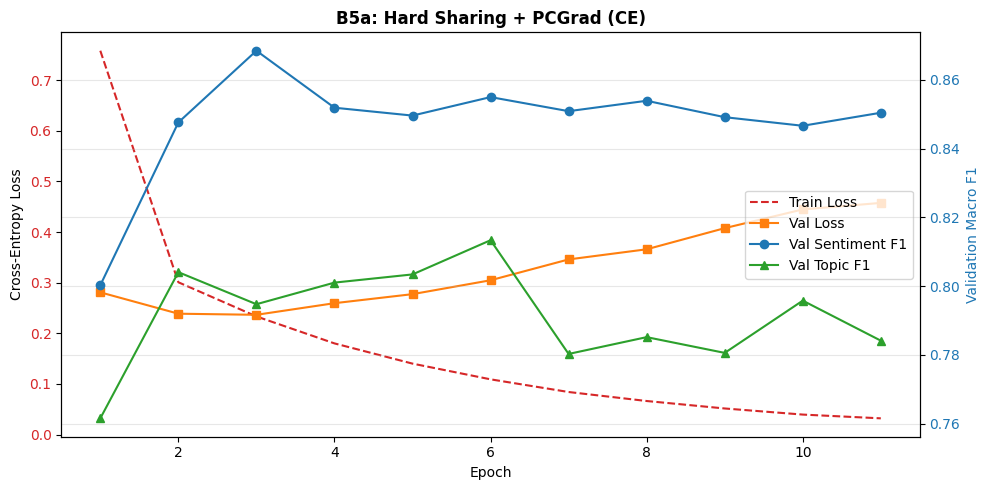


Chấn đoán trên validation === B5a_Hard_PCGrad_CE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9524    0.9660    0.9592       705
     Neutral     0.6875    0.6027    0.6423        73
    Positive     0.9639    0.9627    0.9633       805

    accuracy                         0.9476      1583
   macro avg     0.8680    0.8438    0.8549      1583
weighted avg     0.9461    0.9476    0.9467      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9560    0.9253    0.9404      1151
    Training     0.7340    0.8577    0.7910       267
    Facility     0.9286    0.9286    0.9286        70
      Others     0.6207    0.5684    0.5934        95

    accuracy                         0.8926      1583
   macro avg     0.8098    0.8200    0.8133      1583
weighted avg     0.8972    0.8926    0.8939      1583


=== B5a (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative    

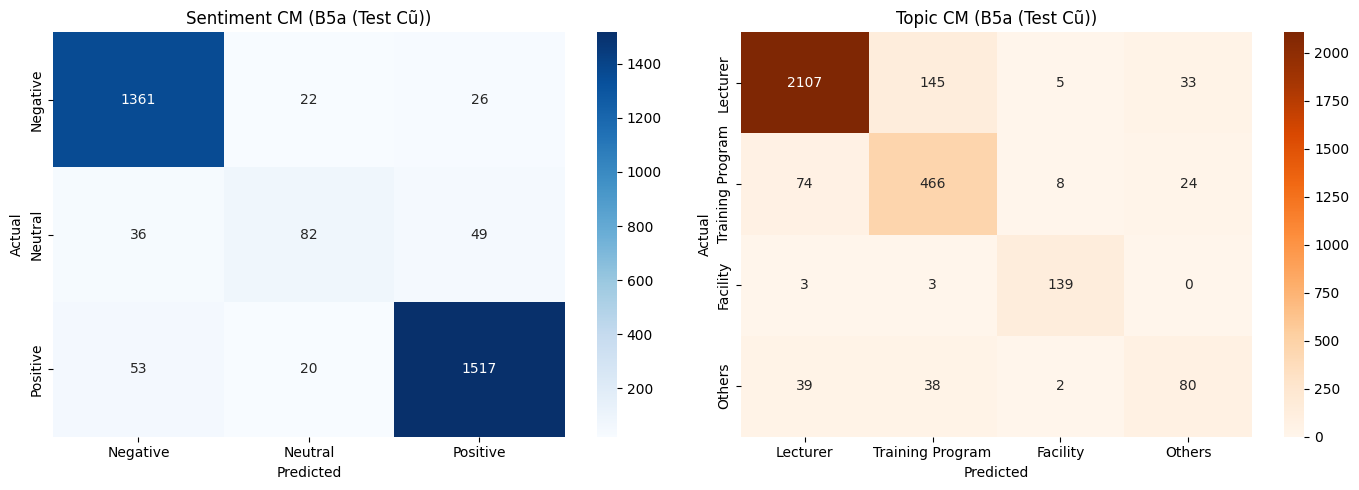


=== B5a (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9469    0.9793    0.9628      1402
     Neutral     0.7016    0.5506    0.6170       158
    Positive     0.9742    0.9658    0.9700      1606

    accuracy                         0.9510      3166
   macro avg     0.8743    0.8319    0.8499      3166
weighted avg     0.9485    0.9510    0.9492      3166


=== B5a (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9681    0.9385    0.9531      2293
Training Program     0.7945    0.8765    0.8335       591
        Facility     0.9351    0.9863    0.9600       146
          Others     0.6569    0.6618    0.6593       136

        accuracy                         0.9172      3166
       macro avg     0.8386    0.8658    0.8515      3166
    weighted avg     0.9208    0.9172    0.9184      3166



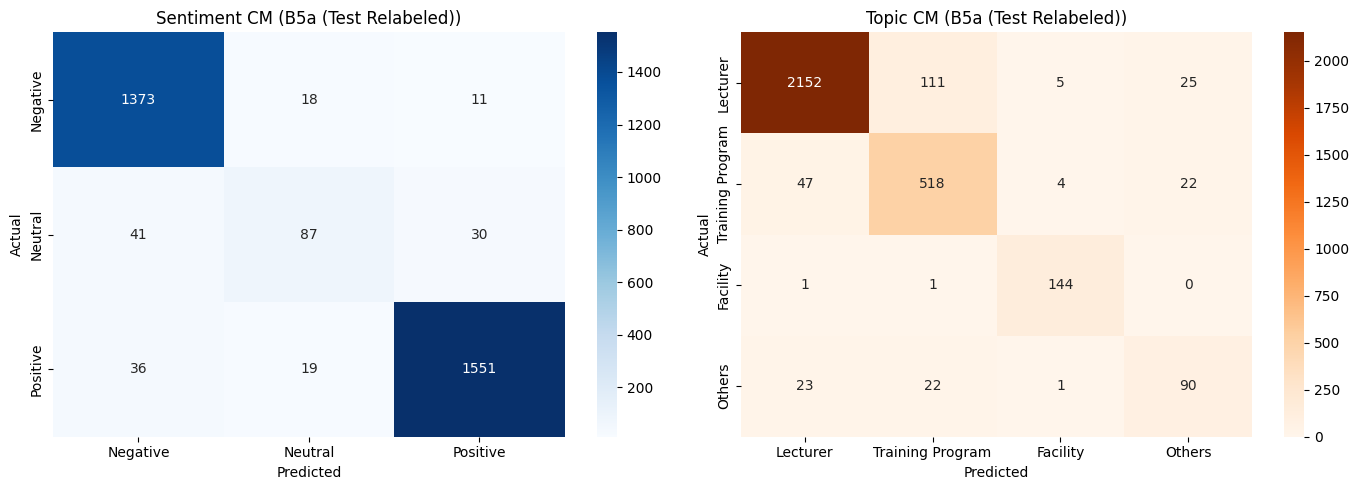


B5b: MTL Hard Sharing + PCGrad + Weighted CE (Class Weights)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.9320 | Val Loss: 0.4423 | Sent F1: 0.7715 | Topic F1: 0.7165 | Avg F1: 0.7440
  ↑ New best Avg F1: 0.7440
Epoch 02 | Train Loss: 0.4000 | Val Loss: 0.3811 | Sent F1: 0.8385 | Topic F1: 0.7850 | Avg F1: 0.8118
  ↑ New best Avg F1: 0.8118
Epoch 03 | Train Loss: 0.3015 | Val Loss: 0.3865 | Sent F1: 0.8363 | Topic F1: 0.7718 | Avg F1: 0.8041
  No improve 1/5
Epoch 04 | Train Loss: 0.2298 | Val Loss: 0.4367 | Sent F1: 0.8454 | Topic F1: 0.7696 | Avg F1: 0.8075
  No improve 2/5
Epoch 05 | Train Loss: 0.1725 | Val Loss: 0.4645 | Sent F1: 0.8516 | Topic F1: 0.7807 | Avg F1: 0.8161
  ↑ New best Avg F1: 0.8161
Epoch 06 | Train Loss: 0.1302 | Val Loss: 0.5353 | Sent F1: 0.8606 | Topic F1: 0.7809 | Avg F1: 0.8207
  ↑ New best Avg F1: 0.8207
Epoch 07 | Train Loss: 0.1005 | Val Loss: 0.5785 | Sent F1: 0.8587 | Topic F1: 0.7885 | Avg F1: 0.8236
  ↑ New best Avg F1: 0.8236
Epoch 08 | Train Loss: 0.0787 | Val Loss: 0.6429 | Sent F1: 0.8452 | Topic F1: 0.7764 | Avg F1: 0.8108
  

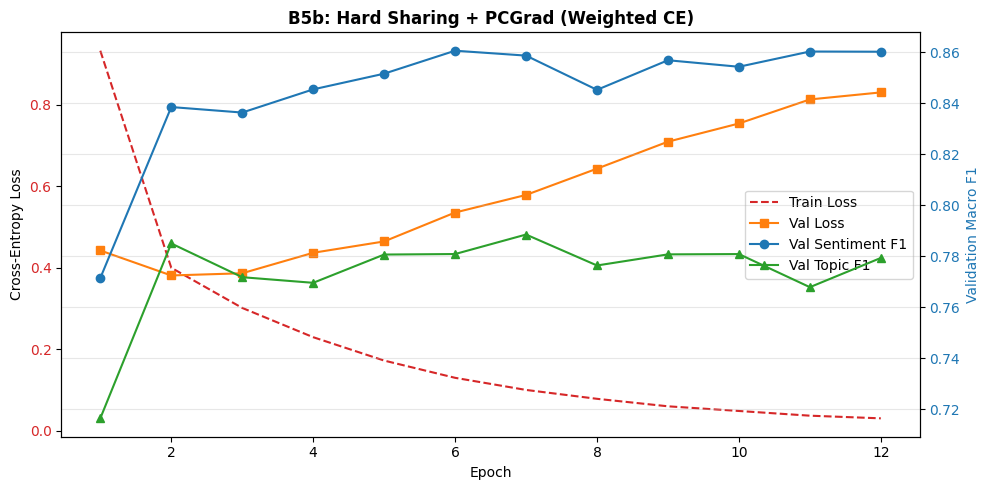


Chấn đoán trên validation === B5b_Hard_PCGrad_WCE ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9601    0.9560    0.9581       705
     Neutral     0.6364    0.6712    0.6533        73
    Positive     0.9652    0.9640    0.9646       805

    accuracy                         0.9469      1583
   macro avg     0.8539    0.8637    0.8587      1583
weighted avg     0.9478    0.9469    0.9473      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9586    0.9062    0.9317      1151
    Training     0.7213    0.8240    0.7692       267
    Facility     0.8800    0.9429    0.9103        70
      Others     0.4957    0.6000    0.5429        95

    accuracy                         0.8756      1583
   macro avg     0.7639    0.8182    0.7885      1583
weighted avg     0.8873    0.8756    0.8800      1583


=== B5b (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative   

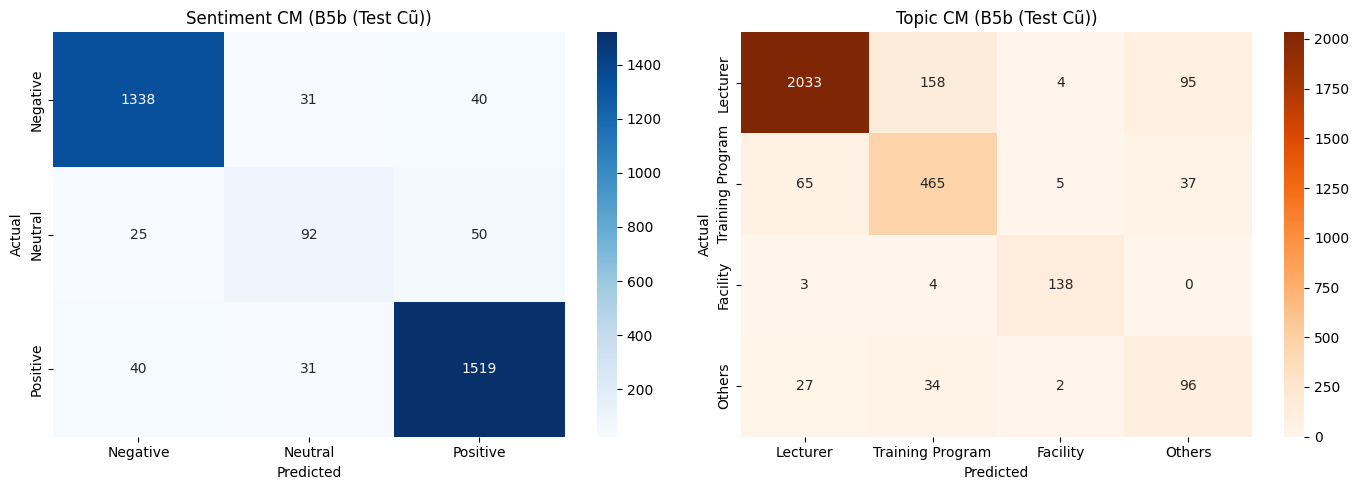


=== B5b (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9622    0.9629    0.9626      1402
     Neutral     0.6429    0.6266    0.6346       158
    Positive     0.9671    0.9689    0.9680      1606

    accuracy                         0.9491      3166
   macro avg     0.8574    0.8528    0.8550      3166
weighted avg     0.9487    0.9491    0.9489      3166


=== B5b (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9756    0.9054    0.9392      2293
Training Program     0.7852    0.8782    0.8291       591
        Facility     0.9530    0.9726    0.9627       146
          Others     0.4474    0.7500    0.5604       136

        accuracy                         0.8967      3166
       macro avg     0.7903    0.8765    0.8228      3166
    weighted avg     0.9163    0.8967    0.9034      3166



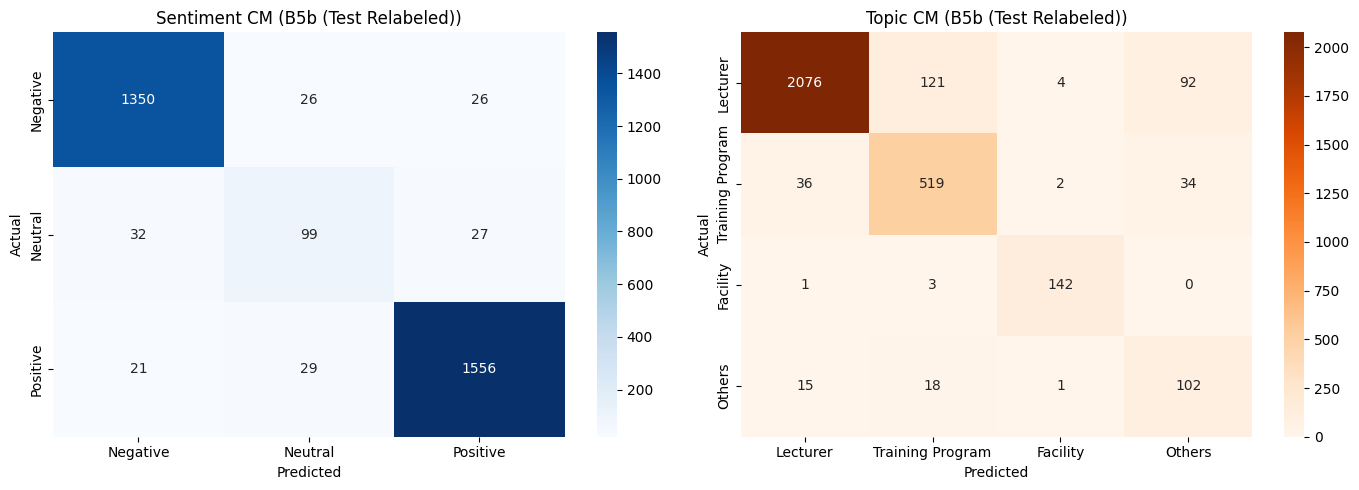


B5c: MTL Hard Sharing + PCGrad + Focal Loss


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.0642 | Val Loss: 0.0228 | Sent F1: 0.7664 | Topic F1: 0.7030 | Avg F1: 0.7347
  ↑ New best Avg F1: 0.7347
Epoch 02 | Train Loss: 0.0241 | Val Loss: 0.0216 | Sent F1: 0.7385 | Topic F1: 0.7632 | Avg F1: 0.7509
  ↑ New best Avg F1: 0.7509
Epoch 03 | Train Loss: 0.0175 | Val Loss: 0.0207 | Sent F1: 0.8178 | Topic F1: 0.7722 | Avg F1: 0.7950
  ↑ New best Avg F1: 0.7950
Epoch 04 | Train Loss: 0.0132 | Val Loss: 0.0230 | Sent F1: 0.8232 | Topic F1: 0.7683 | Avg F1: 0.7957
  ↑ New best Avg F1: 0.7957
Epoch 05 | Train Loss: 0.0099 | Val Loss: 0.0295 | Sent F1: 0.8364 | Topic F1: 0.7521 | Avg F1: 0.7943
  No improve 1/5
Epoch 06 | Train Loss: 0.0079 | Val Loss: 0.0296 | Sent F1: 0.8411 | Topic F1: 0.7567 | Avg F1: 0.7989
  ↑ New best Avg F1: 0.7989
Epoch 07 | Train Loss: 0.0061 | Val Loss: 0.0336 | Sent F1: 0.8495 | Topic F1: 0.7836 | Avg F1: 0.8166
  ↑ New best Avg F1: 0.8166
Epoch 08 | Train Loss: 0.0048 | Val Loss: 0.0340 | Sent F1: 0.8267 | Topic F1: 0.7745 | Avg F1

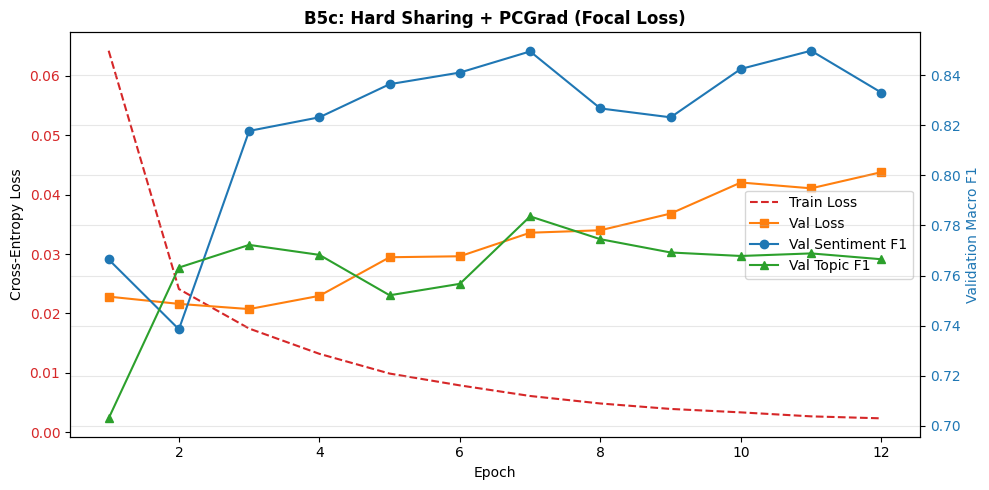


Chấn đoán trên validation === B5c_Hard_PCGrad_FocalLoss ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9558    0.9504    0.9531       705
     Neutral     0.6184    0.6438    0.6309        73
    Positive     0.9640    0.9652    0.9646       805

    accuracy                         0.9438      1583
   macro avg     0.8461    0.8531    0.8495      1583
weighted avg     0.9444    0.9438    0.9441      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9499    0.9218    0.9356      1151
    Training     0.7087    0.8202    0.7604       267
    Facility     0.9000    0.9000    0.9000        70
      Others     0.5632    0.5158    0.5385        95

    accuracy                         0.8793      1583
   macro avg     0.7805    0.7895    0.7836      1583
weighted avg     0.8838    0.8793    0.8807      1583


=== B5c (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negat

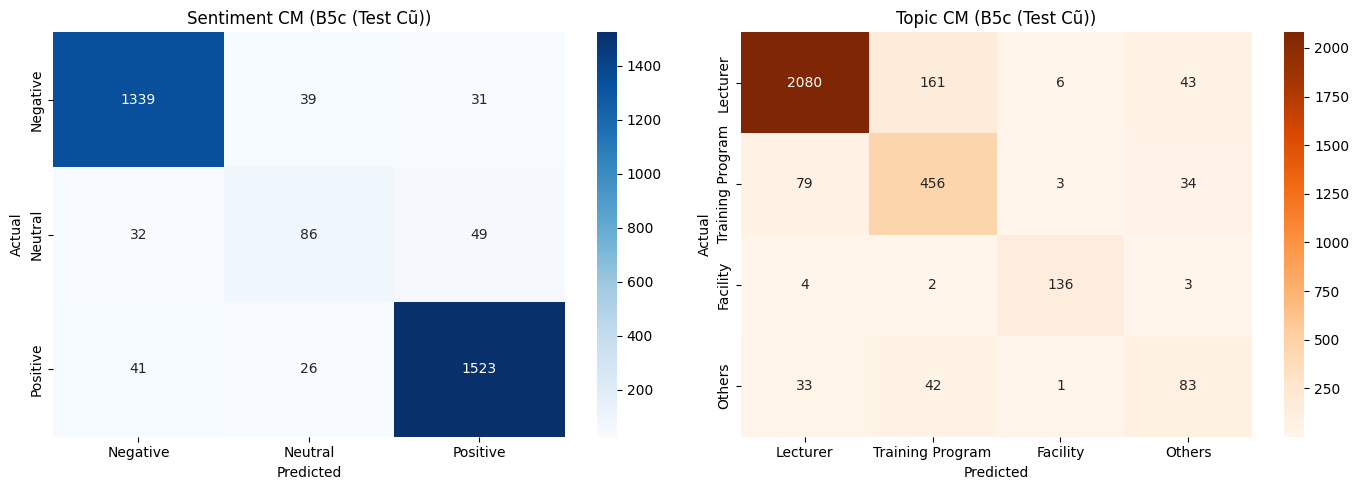


=== B5c (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9582    0.9650    0.9616      1402
     Neutral     0.6358    0.6076    0.6214       158
    Positive     0.9744    0.9726    0.9735      1606

    accuracy                         0.9510      3166
   macro avg     0.8561    0.8484    0.8522      3166
weighted avg     0.9503    0.9510    0.9507      3166


=== B5c (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9690    0.9280    0.9481      2293
Training Program     0.7685    0.8596    0.8115       591
        Facility     0.9521    0.9521    0.9521       146
          Others     0.5644    0.6765    0.6154       136

        accuracy                         0.9056      3166
       macro avg     0.8135    0.8540    0.8318      3166
    weighted avg     0.9134    0.9056    0.9085      3166



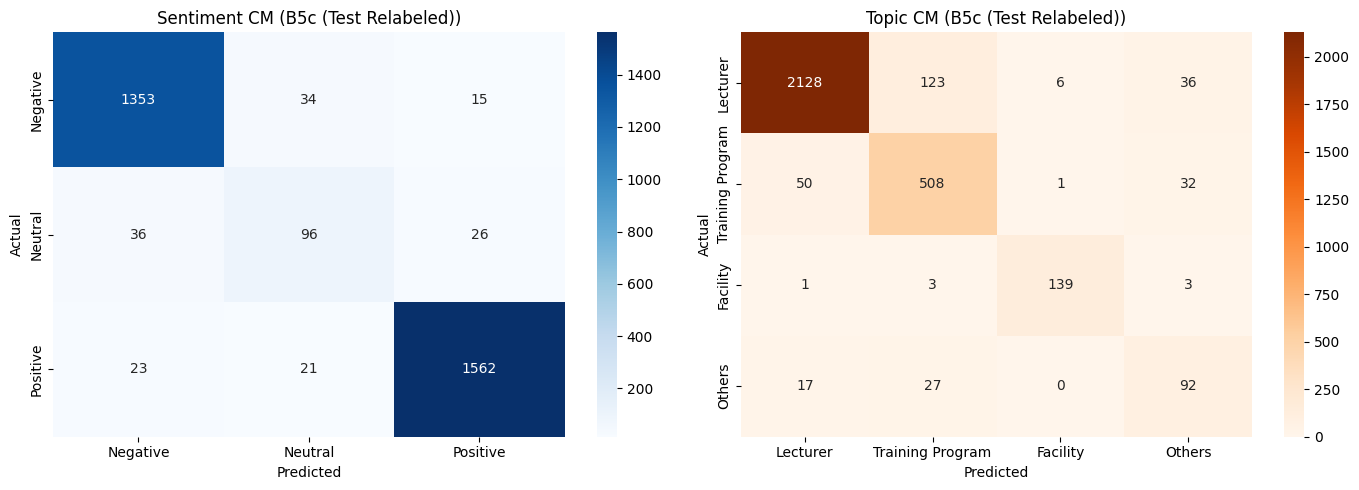


B5d: MTL Hard Sharing + PCGrad + Asymmetric Loss (ASL)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.6645 | Val Loss: 0.2137 | Sent F1: 0.7961 | Topic F1: 0.7462 | Avg F1: 0.7712
  ↑ New best Avg F1: 0.7712
Epoch 02 | Train Loss: 0.2468 | Val Loss: 0.1872 | Sent F1: 0.8538 | Topic F1: 0.7938 | Avg F1: 0.8238
  ↑ New best Avg F1: 0.8238
Epoch 03 | Train Loss: 0.1924 | Val Loss: 0.2011 | Sent F1: 0.8499 | Topic F1: 0.7728 | Avg F1: 0.8113
  No improve 1/5
Epoch 04 | Train Loss: 0.1524 | Val Loss: 0.1933 | Sent F1: 0.8515 | Topic F1: 0.7951 | Avg F1: 0.8233
  No improve 2/5
Epoch 05 | Train Loss: 0.1186 | Val Loss: 0.2244 | Sent F1: 0.8457 | Topic F1: 0.7579 | Avg F1: 0.8018
  No improve 3/5
Epoch 06 | Train Loss: 0.0952 | Val Loss: 0.2360 | Sent F1: 0.8389 | Topic F1: 0.7707 | Avg F1: 0.8048
  No improve 4/5
Epoch 07 | Train Loss: 0.0774 | Val Loss: 0.2580 | Sent F1: 0.8391 | Topic F1: 0.7850 | Avg F1: 0.8121
  No improve 5/5
  Early stopping at epoch 7

Best avg macro F1 (val): 0.8238


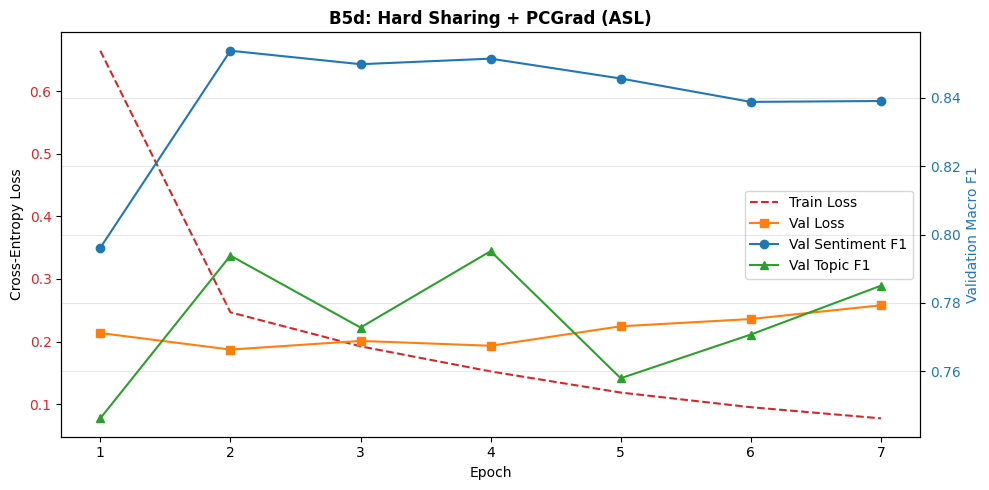


Chấn đoán trên validation === B5d_Hard_PCGrad_ASL ===
SENTIMENT:
              precision    recall  f1-score   support

    Negative     0.9590    0.9631    0.9611       705
     Neutral     0.5862    0.6986    0.6375        73
    Positive     0.9734    0.9528    0.9630       805

    accuracy                         0.9457      1583
   macro avg     0.8395    0.8715    0.8538      1583
weighted avg     0.9491    0.9457    0.9471      1583

TOPIC:
              precision    recall  f1-score   support

    Lecturer     0.9493    0.9279    0.9385      1151
    Training     0.7766    0.7940    0.7852       267
    Facility     0.9275    0.9143    0.9209        70
      Others     0.4828    0.5895    0.5308        95

    accuracy                         0.8844      1583
   macro avg     0.7840    0.8064    0.7938      1583
weighted avg     0.8912    0.8844    0.8874      1583


=== B5d (Test Cũ): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative   

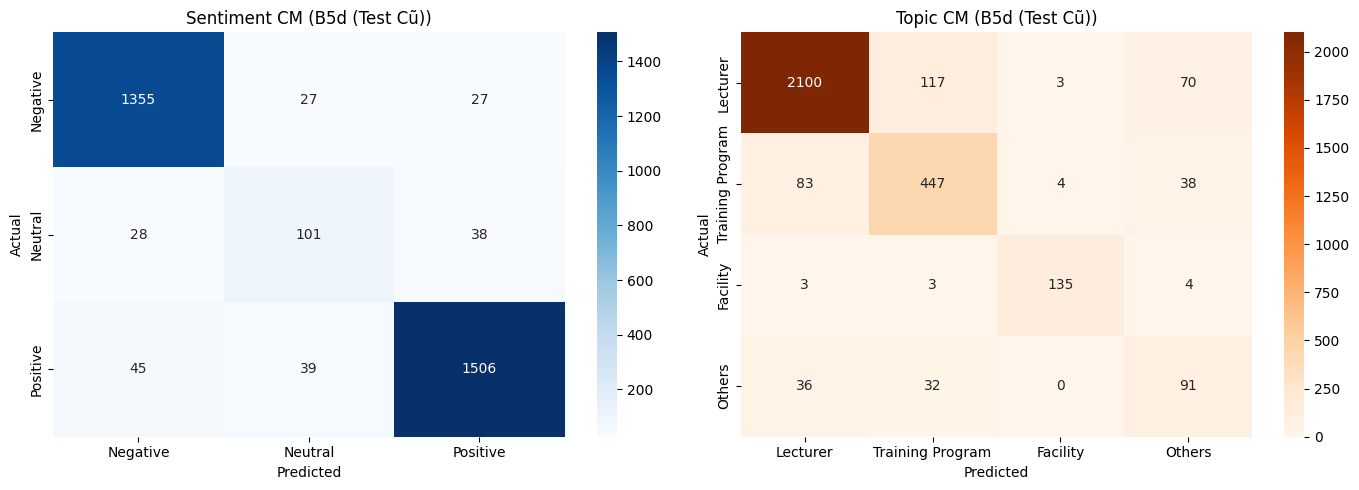


=== B5d (Test Relabeled): SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative     0.9573    0.9750    0.9661      1402
     Neutral     0.6347    0.6709    0.6523       158
    Positive     0.9815    0.9601    0.9707      1606

    accuracy                         0.9523      3166
   macro avg     0.8579    0.8687    0.8630      3166
weighted avg     0.9535    0.9523    0.9528      3166


=== B5d (Test Relabeled): TOPIC REPORT ===
                  precision    recall  f1-score   support

        Lecturer     0.9671    0.9372    0.9519      2293
Training Program     0.8397    0.8511    0.8454       591
        Facility     0.9718    0.9452    0.9583       146
          Others     0.5025    0.7500    0.6018       136

        accuracy                         0.9135      3166
       macro avg     0.8203    0.8709    0.8394      3166
    weighted avg     0.9236    0.9135    0.9173      3166



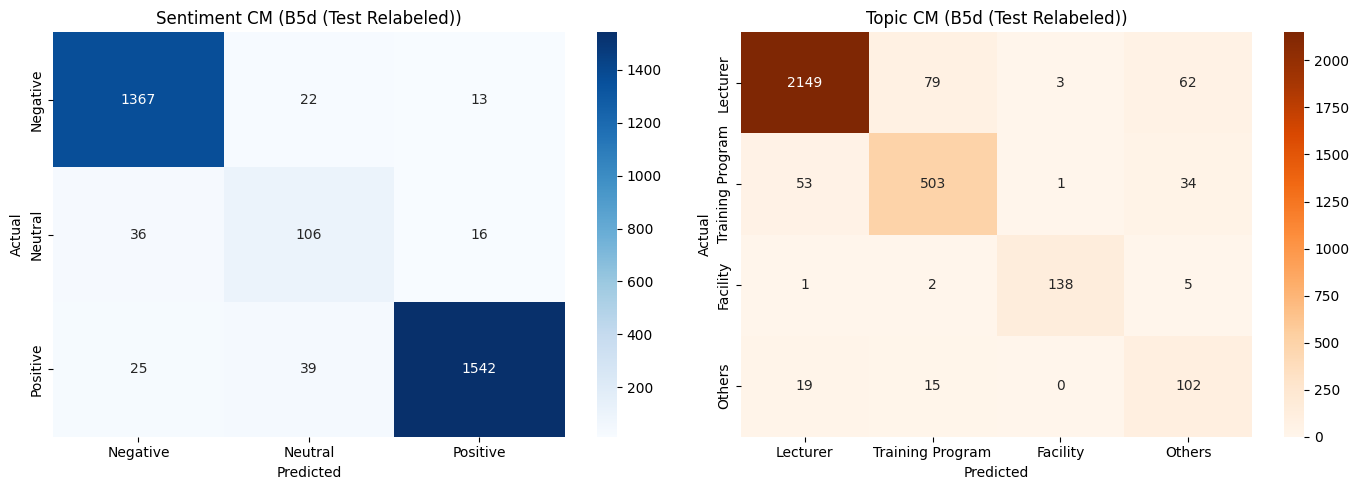


ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST CŨ (OLD TEST SET)
                           Avg Macro F1  Sent macro-F1  S-Negative  S-Neutral*  S-Positive  Topic macro-F1  T-Lecturer  T-Training  T-Facility*  T-Others*
Model                                                                                                                                                     
B5a_Hard_PCGrad_CE               0.8072         0.8230      0.9521      0.5636      0.9535          0.7914      0.9337      0.7614       0.9298     0.5405
B5b_Hard_PCGrad_WCE              0.8011         0.8248      0.9516      0.5732      0.9497          0.7774      0.9203      0.7543       0.9388     0.4961
B5c_Hard_PCGrad_FocalLoss        0.7970         0.8147      0.9493      0.5409      0.9540          0.7793      0.9273      0.7397       0.9347     0.5155
B5d_Hard_PCGrad_ASL              0.8110         0.8376      0.9552      0.6048      0.9529          0.7845      0.9309      0.7635       0.9408     0.5028

ABLATION ST

In [ ]:
# CHẠY THỰC NGHIỆM & ĐÁNH GIÁ TRÊN 2 TẬP TEST
results_old_test = {}
results_new_test = {}

# 1. Standard Cross Entropy (CE)
ce_sent  = nn.CrossEntropyLoss()
ce_topic = nn.CrossEntropyLoss()

# 2. Weighted Cross Entropy (WCE) - Tích hợp Class Weights
wce_sent  = nn.CrossEntropyLoss(weight=sent_weights.to(DEVICE))
wce_topic = nn.CrossEntropyLoss(weight=topic_weights.to(DEVICE))

# 3. Focal Loss
focal_sent  = FocalLoss(alpha=sent_focal_alpha,  gamma=2.0).to(DEVICE)
focal_topic = FocalLoss(alpha=topic_focal_alpha, gamma=3.0).to(DEVICE)

# 4. Asymmetric Loss (ASL)
asl_sent = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 4.0, 0.0],  
    gamma_pos_list=[2.0, 1.0, 2.0]   
).to(DEVICE)

asl_topic = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 0.0, 0.0, 4.0], 
    gamma_pos_list=[2.0, 2.0, 2.0, 1.0]
).to(DEVICE)

# CHẠY THỰC NGHIỆM: NHÓM B5 (MTL HARD SHARING + PCGrad)
# ── B5a: MTL Hard Sharing + PCGrad + Standard CE ──
print("\n" + "="*60)
print("B5a: MTL Hard Sharing + PCGrad + Standard CE (Lambda 0.6/0.4)")
print("="*60)

# 1. Khởi tạo đúng mô hình và biến
model_b5a = MTLHardSharing(dropout=0.3).to(DEVICE)

# 2. Gọi hàm train_pcgrad thay vì train_mtl
model_b5a, hist_b5a, val_f1_b5a = train_pcgrad(
    model=model_b5a, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=ce_sent,      # Chú ý tên tham số của hàm PCGrad
    loss_topic_fn=ce_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B5a_Hard_PCGrad_CE"
)

# 3. Đánh giá và lưu kết quả với đúng tên biến B5a
plot_mtl_history(hist_b5a, title="B5a: Hard Sharing + PCGrad (CE)")
diagnose_validation(model_b5a, val_loader, "B5a_Hard_PCGrad_CE") 
results_old_test["B5a_Hard_PCGrad_CE"] = evaluate_and_plot_mtl(model_b5a, test_loader, title_prefix="B5a (Test Cũ)")
results_new_test["B5a_Hard_PCGrad_CE"] = evaluate_and_plot_mtl(model_b5a, test_loader1, title_prefix="B5a (Test Relabeled)")

# ── B5b: MTL Hard Sharing + PCGrad + Weighted CE ──
print("\n" + "="*60)
print("B5b: MTL Hard Sharing + PCGrad + Weighted CE (Class Weights)")
print("="*60)

model_b5b = MTLHardSharing(dropout=0.3).to(DEVICE)

model_b5b, hist_b5b, val_f1_b5b = train_pcgrad(
    model=model_b5b, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=wce_sent,       # Dùng Weighted CE
    loss_topic_fn=wce_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B5b_Hard_PCGrad_WCE"
)

plot_mtl_history(hist_b5b, title="B5b: Hard Sharing + PCGrad (Weighted CE)")
diagnose_validation(model_b5b, val_loader, "B5b_Hard_PCGrad_WCE") 
results_old_test["B5b_Hard_PCGrad_WCE"] = evaluate_and_plot_mtl(model_b5b, test_loader, title_prefix="B5b (Test Cũ)")
results_new_test["B5b_Hard_PCGrad_WCE"] = evaluate_and_plot_mtl(model_b5b, test_loader1, title_prefix="B5b (Test Relabeled)")


# ── B5c: MTL Hard Sharing + PCGrad + Focal Loss ──
print("\n" + "="*60)
print("B5c: MTL Hard Sharing + PCGrad + Focal Loss")
print("="*60)

model_b5c = MTLHardSharing(dropout=0.3).to(DEVICE)

model_b5c, hist_b5c, val_f1_b5c = train_pcgrad(
    model=model_b5c, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=focal_sent,       # Dùng Focal Loss
    loss_topic_fn=focal_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B5c_Hard_PCGrad_FocalLoss"
)

plot_mtl_history(hist_b5c, title="B5c: Hard Sharing + PCGrad (Focal Loss)")
diagnose_validation(model_b5c, val_loader, "B5c_Hard_PCGrad_FocalLoss") 
results_old_test["B5c_Hard_PCGrad_FocalLoss"] = evaluate_and_plot_mtl(model_b5c, test_loader, title_prefix="B5c (Test Cũ)")
results_new_test["B5c_Hard_PCGrad_FocalLoss"] = evaluate_and_plot_mtl(model_b5c, test_loader1, title_prefix="B5c (Test Relabeled)")


# ── B5d: MTL Hard Sharing + PCGrad + Asymmetric Loss (ASL) ──
print("\n" + "="*60)
print("B5d: MTL Hard Sharing + PCGrad + Asymmetric Loss (ASL)")
print("="*60)

model_b5d = MTLHardSharing(dropout=0.3).to(DEVICE)

model_b5d, hist_b5d, val_f1_b5d = train_pcgrad(
    model=model_b5d, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    loss_sent_fn=asl_sent,       # Dùng Asymmetric Loss
    loss_topic_fn=asl_topic, 
    lambda_s=0.6, 
    lambda_t=0.4, 
    model_name="B5d_Hard_PCGrad_ASL"
)

plot_mtl_history(hist_b5d, title="B5d: Hard Sharing + PCGrad (ASL)")
diagnose_validation(model_b5d, val_loader, "B5d_Hard_PCGrad_ASL") 
results_old_test["B5d_Hard_PCGrad_ASL"] = evaluate_and_plot_mtl(model_b5d, test_loader, title_prefix="B5d (Test Cũ)")
results_new_test["B5d_Hard_PCGrad_ASL"] = evaluate_and_plot_mtl(model_b5d, test_loader1, title_prefix="B5d (Test Relabeled)")



# 6. IN BẢNG SO SÁNH KẾT QUẢ CHO CẢ 2 TEST SET
def extract_per_class_f1(report, classes):
    return {c: round(report[c]["f1-score"], 4) for c in classes}

def generate_result_dataframe(results_dict):
    rows = []
    for name, res in results_dict.items():
        s_per = extract_per_class_f1(res["sent_report"], ["Negative","Neutral","Positive"])
        t_per = extract_per_class_f1(res["topic_report"], ["Lecturer","Training Program","Facility","Others"])
        rows.append({
            "Model":            name,
            "Avg Macro F1":     round((res["sent_macro_f1"] + res["topic_macro_f1"])/2, 4),
            "Sent macro-F1":    round(res["sent_macro_f1"], 4),
            "S-Negative":       s_per["Negative"],
            "S-Neutral*":       s_per["Neutral"],      
            "S-Positive":       s_per["Positive"],
            "Topic macro-F1":   round(res["topic_macro_f1"], 4),
            "T-Lecturer":       t_per["Lecturer"],
            "T-Training":       t_per["Training Program"],
            "T-Facility*":      t_per["Facility"],     
            "T-Others*":        t_per["Others"],       
        })
    return pd.DataFrame(rows).set_index("Model")

df_results_old = generate_result_dataframe(results_old_test)
df_results_new = generate_result_dataframe(results_new_test)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST CŨ (OLD TEST SET)")
print("=" * 110)
print(df_results_old.to_string())

print("\n" + "=" * 110)
print("ABLATION STUDY — KẾT QUẢ TRÊN TẬP TEST ĐÃ SỬA NHÃN (RELABELED TEST SET)")
print("=" * 110)
print(df_results_new.to_string())
print("\n(*) Ghi chú: Các lớp có dấu * là lớp thiểu số mất cân bằng dữ liệu.")